In [14]:
# Regression Project: California Housing Price Prediction
# Steps: Data Gathering → Visualization → Model Training → Deployment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
# 1. Data Gathering
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='PRICE')

df = X.copy()
df['PRICE'] = y

print("=== Step 1: Data Gathering & Exploration ===")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Basic Information
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

=== Step 1: Data Gathering & Exploration ===
Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float

In this step, we load the California Housing dataset from scikit-learn. We explore the dataset structure, check for missing values, and generate summary statistics to understand the data better.

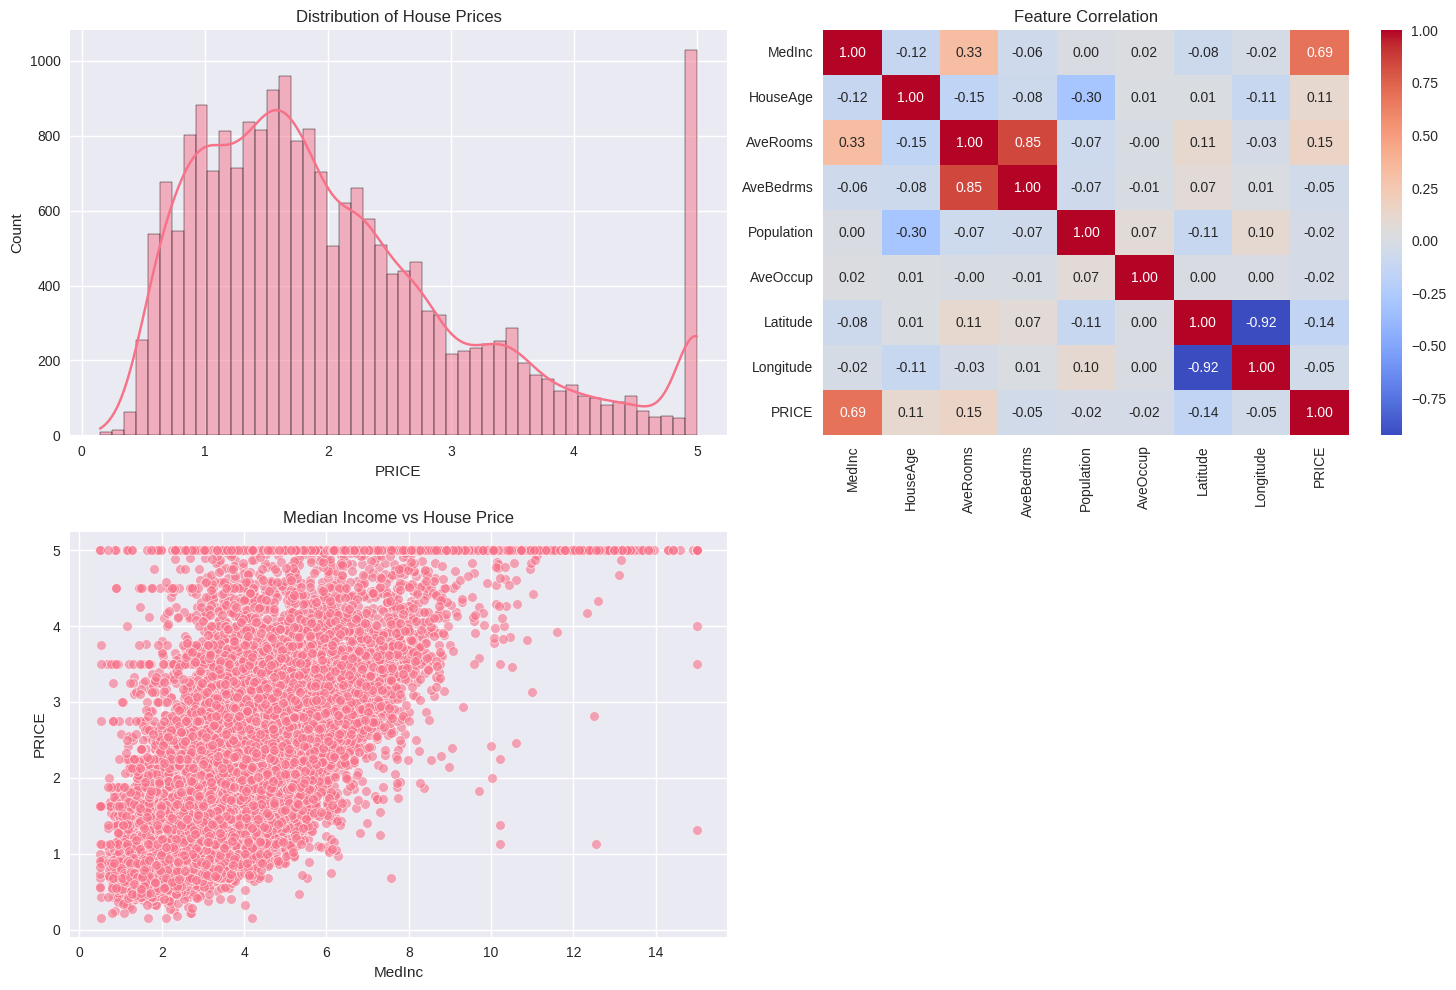


=== Model Selection ===
• Strong correlation between MedInc and PRICE → Linear Regression is suitable
• Non-linear relationships also exist → Random Forest Regressor will be tested


In [16]:
# 2. Data Visualisation
plt.figure(figsize=(15, 10))

# Distribution of Target Variable
plt.subplot(2, 2, 1)
sns.histplot(df['PRICE'], kde=True, bins=50)
plt.title('Distribution of House Prices')

# Correlation Heatmap
plt.subplot(2, 2, 2)
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')

# Median Income vs Price
plt.subplot(2, 2, 3)
sns.scatterplot(x='MedInc', y='PRICE', data=df, alpha=0.6)
plt.title('Median Income vs House Price')

plt.tight_layout()
plt.show()

# Model Selection Reasoning:
print("\n=== Model Selection ===")
print("• Strong correlation between MedInc and PRICE → Linear Regression is suitable")
print("• Non-linear relationships also exist → Random Forest Regressor will be tested")

Here we visualize the distribution of house prices, feature correlations, and relationships between key variables. These insights help us choose appropriate regression models.

In [12]:
# 3. Model Training & Testing

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Two Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"\n{name} Performance:")
    print(f"MAE: ${mae:.4f} (thousands)")
    print(f"RMSE: ${rmse:.4f} (thousands)")
    print(f"R² Score: {r2:.4f}")

# Best Model
best_model = max(results, key=lambda x: results[x]['R2'])
print(f"\n✅ Best Model: {best_model}")


Linear Regression Performance:
MAE: $0.5332 (thousands)
RMSE: $0.7456 (thousands)
R² Score: 0.5758

Random Forest Performance:
MAE: $0.3274 (thousands)
RMSE: $0.5051 (thousands)
R² Score: 0.8053

✅ Best Model: Random Forest


We train two regression models — Linear Regression and Random Forest Regressor. We evaluate them using MAE, RMSE, and R² Score to determine the best performing model

In [13]:
# 4. Model Deployment (Save Model + Simple Inference Function)

import joblib

# Save the best model and scaler
best_model_obj = models[best_model]
joblib.dump(best_model_obj, 'california_house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model and Scaler saved successfully!")

# Deployment / Inference Function
def predict_house_price(medinc, houseage, ave_rooms, ave_bedrms, population, ave_occup, latitude, longitude):
    input_data = np.array([[medinc, houseage, ave_rooms, ave_bedrms,
                          population, ave_occup, latitude, longitude]])
    scaled_input = scaler.transform(input_data)
    prediction = best_model_obj.predict(scaled_input)
    return prediction[0] * 100000  # Convert to actual dollars

# Test Prediction
print("\n🧪 Sample Prediction:")
price = predict_house_price(8.3252, 41.0, 6.984, 1.024, 322.0, 2.555, 37.88, -122.23)
print(f"Predicted House Price: ${price:,.2f}")

✅ Model and Scaler saved successfully!

🧪 Sample Prediction:
Predicted House Price: $423,210.28


In the final step, we save the best model and scaler for future use. We also create a prediction function that simulates real-world deployment